In [19]:
import pandas as pd

excel_file = pd.ExcelFile('rooster.xlsx')

excel_file.sheet_names

['customers', 'orders', 'orderlines', 'products', 'metadata']

In [43]:

#DATA EXPLORATION & QUALITY ASSESMENT
customers = pd.read_excel(

'rooster.xlsx',

sheet_name='customers')
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6606 entries, 0 to 6605
Data columns (total 9 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   customer_email                   6606 non-null   object        
 1   customer_first_order_date        6606 non-null   datetime64[ns]
 2   customer_last_order_date         6606 non-null   datetime64[ns]
 3   customer_total_orders            6606 non-null   int64         
 4   customer_total_spent             6606 non-null   float64       
 5   coupon_count                     6606 non-null   int64         
 6   first_order_coupon_code          3019 non-null   object        
 7   first_order_used_coupon          6606 non-null   int64         
 8   first_order_acquisition_channel  6606 non-null   object        
dtypes: datetime64[ns](2), float64(1), int64(3), object(3)
memory usage: 464.6+ KB


In [21]:
customers.describe()

,customer_first_order_date,customer_last_order_date,customer_total_orders,customer_total_spent,coupon_count,first_order_used_coupon
count,6606,6606,6606.000000,6606.000000,6606.000000,6606.000000
mean,2024-10-01 16:57:19.782016256,2024-11-16 19:32:45.122615808,1.528913,72.375982,0.599909,0.457009
min,2023-10-16 00:00:00,2023-10-16 00:00:00,1.000000,0.000000,0.000000,0.000000
25%,2024-06-06 00:00:00,2024-07-31 00:00:00,1.000000,31.630000,0.000000,0.000000
50%,2024-10-16 00:00:00,2024-12-04 00:00:00,1.000000,51.600000,0.000000,0.000000
75%,2024-12-29 00:00:00,2025-03-13 00:00:00,2.000000,92.792500,1.000000,1.000000
max,2025-06-30 00:00:00,2025-06-30 00:00:00,10.000000,834.410000,7.000000,1.000000
std,NaN,NaN,0.927009,65.408082,0.792810,0.498186


In [33]:
customers.isnull().sum()

,0
customer_email,0
customer_first_order_date,0
customer_last_order_date,0
customer_total_orders,0
customer_total_spent,0
coupon_count,0
first_order_coupon_code,3587
first_order_used_coupon,0
first_order_acquisition_channel,0


In [34]:
(customers.isnull().sum() / len(customers) * 100).round(2)

,0
customer_email,0.0
customer_first_order_date,0.0
customer_last_order_date,0.0
customer_total_orders,0.0
customer_total_spent,0.0
coupon_count,0.0
first_order_coupon_code,54.3
first_order_used_coupon,0.0
first_order_acquisition_channel,0.0


In [35]:
customers.duplicated().sum()

np.int64(50)

In [36]:
customers.dtypes

,0
customer_email,object
customer_first_order_date,datetime64[ns]
customer_last_order_date,datetime64[ns]
customer_total_orders,int64
customer_total_spent,float64
coupon_count,int64
first_order_coupon_code,object
first_order_used_coupon,int64
first_order_acquisition_channel,object


In [37]:
customers['first_order_used_coupon'].value_counts()

,count
first_order_used_coupon,
0,3587
1,3019


In [38]:
customers['first_order_acquisition_channel'].value_counts()

,count
first_order_acquisition_channel,
Direct,1431
Google,1373
Facebook,1334
Unknown,1122
Referral,680
Newsletter,361
Instagram,165
Shopping comparison,136
Messenger,2


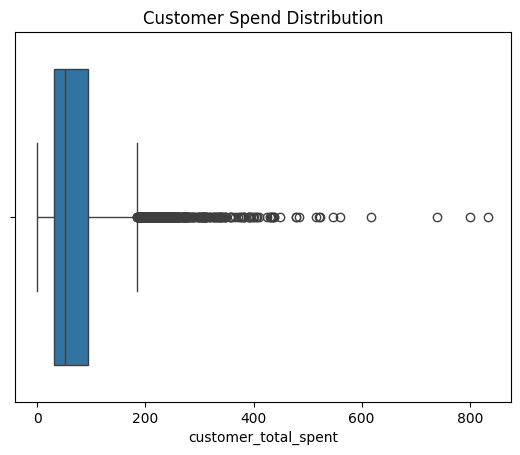

In [39]:
import seaborn as sns

import matplotlib.pyplot as plt

sns.boxplot(x=customers['customer_total_spent'])

plt.title('Customer Spend Distribution')

plt.show()

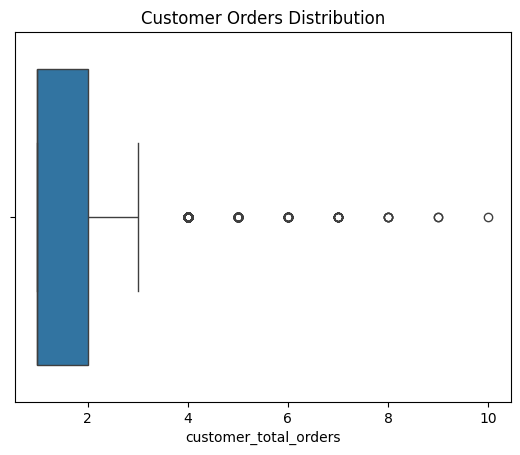

In [42]:
sns.boxplot(x=customers['customer_total_orders'])

plt.title('Customer Orders Distribution')

plt.show()
# END OF DATA EXPLORATION & QUALITY ASSESMENT

In [22]:
# DATA UNDERSTANDING
repeat_customers = (customers['customer_total_orders'] > 1).sum()

total_customers = len(customers)

repeat_rate = repeat_customers / total_customers * 100

print("Total Customers:", total_customers)

print("Repeat Customers:", repeat_customers)

print("Repeat Rate:", round(repeat_rate, 2), "%")

Total Customers: 6606
Repeat Customers: 2255
Repeat Rate: 34.14 %


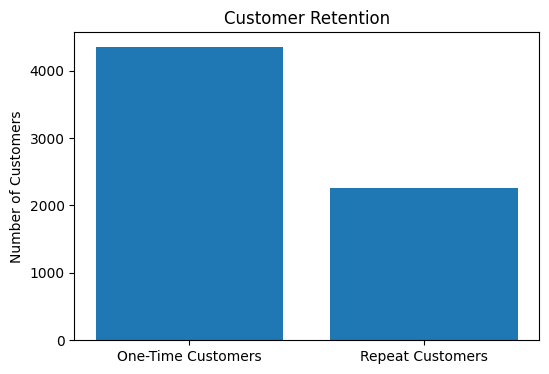

In [23]:
import matplotlib.pyplot as plt

one_time = (customers['customer_total_orders'] == 1).sum()

repeat = (customers['customer_total_orders'] > 1).sum()

plt.figure(figsize=(6,4))

plt.bar(['One-Time Customers', 'Repeat Customers'],

[one_time, repeat])

plt.title('Customer Retention')

plt.ylabel('Number of Customers')

plt.show()

In [24]:
customers.groupby('first_order_acquisition_channel')[['customer_total_orders','customer_total_spent']].mean()

,customer_total_orders,customer_total_spent
first_order_acquisition_channel,,
Direct,1.498952,74.855073
Facebook,1.530735,68.560217
Google,1.523671,75.430277
Instagram,1.400000,64.116242
Messenger,1.500000,27.590000
Newsletter,1.587258,79.396011
Referral,1.623529,74.404882
Shopping comparison,1.647059,75.022426
Source: An,1.000000,18.270000


In [25]:
customers['first_order_acquisition_channel'].value_counts()

,count
first_order_acquisition_channel,
Direct,1431
Google,1373
Facebook,1334
Unknown,1122
Referral,680
Newsletter,361
Instagram,165
Shopping comparison,136
Messenger,2


In [26]:
customers.groupby('first_order_acquisition_channel')['customer_total_orders'].apply(lambda x: (x > 1).mean() * 100)

,customer_total_orders
first_order_acquisition_channel,
Direct,32.704403
Facebook,34.557721
Google,34.450109
Instagram,26.060606
Messenger,50.000000
Newsletter,37.119114
Referral,39.264706
Shopping comparison,40.441176
Source: An,0.000000


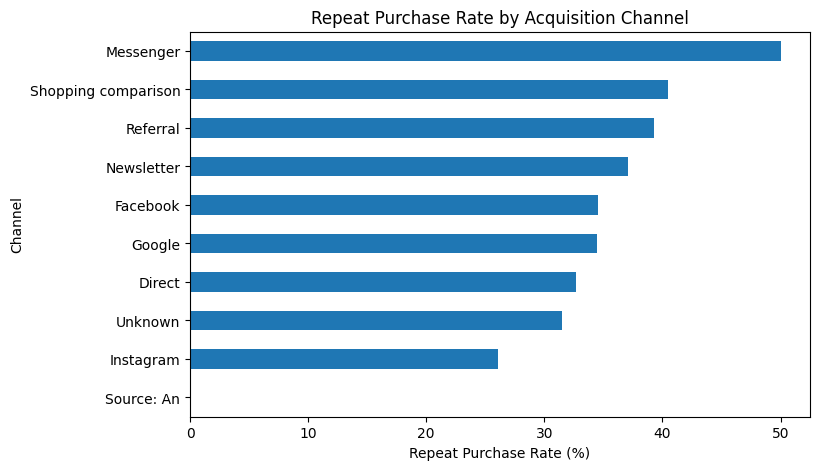

In [27]:
retention_by_channel = customers.groupby(

'first_order_acquisition_channel'

)['customer_total_orders'].apply(

lambda x: (x > 1).mean() * 100

)

retention_by_channel.sort_values().plot(

kind='barh',

figsize=(8,5)
)

plt.title('Repeat Purchase Rate by Acquisition Channel')

plt.xlabel('Repeat Purchase Rate (%)')

plt.ylabel('Channel')

plt.show()

In [28]:
customers.groupby('first_order_used_coupon')[

['customer_total_orders', 'customer_total_spent']

].mean()

,customer_total_orders,customer_total_spent
first_order_used_coupon,,
0,1.276275,58.402306
1,1.829082,88.978692


In [29]:
customers.groupby('first_order_used_coupon')['customer_total_orders'].apply(

lambda x: (x > 1).mean() * 100

)

,customer_total_orders
first_order_used_coupon,
0,21.020351
1,49.718450


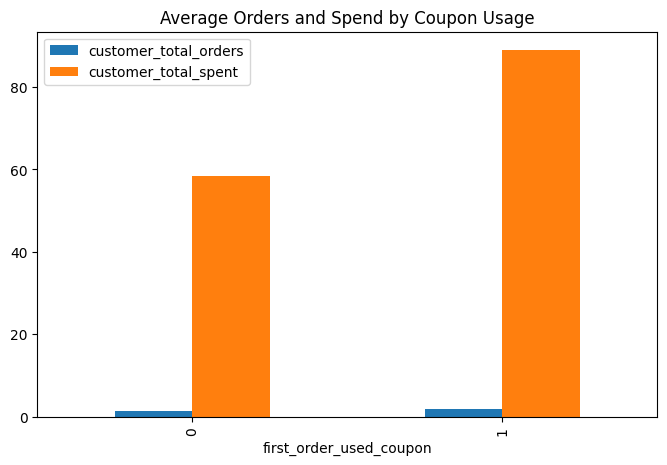

In [50]:
coupon_stats = customers.groupby(
'first_order_used_coupon'
)[['customer_total_orders','customer_total_spent']].mean()
coupon_stats.plot(
kind='bar',
figsize=(8,5)
)
plt.title('Average Orders and Spend by Coupon Usage')
plt.show()

In [45]:
customers['customer_total_orders'].value_counts().sort_index()

,count
customer_total_orders,
1,4351
2,1478
3,503
4,165
5,61
6,28
7,13
8,4
9,2


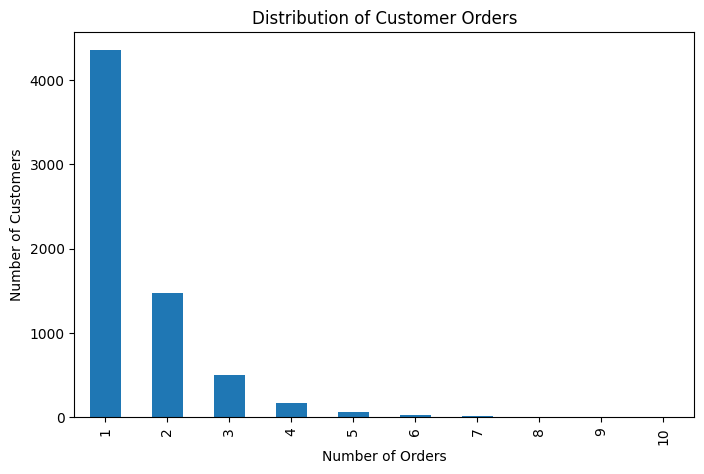

In [47]:
import matplotlib.pyplot as plt

order_distribution = customers['customer_total_orders'].value_counts().sort_index()

order_distribution.plot(

kind='bar',

figsize=(8,5)
)


plt.title('Distribution of Customer Orders')

plt.xlabel('Number of Orders')

plt.ylabel('Number of Customers')

plt.show()

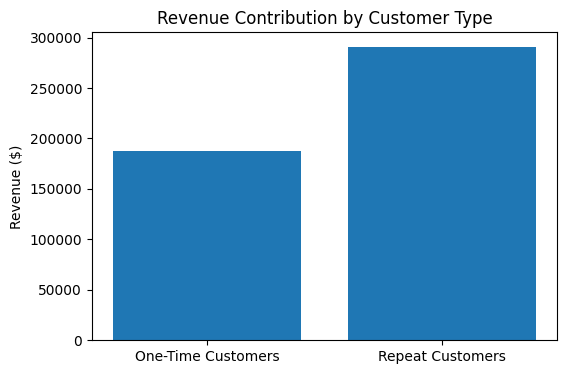

In [49]:
import matplotlib.pyplot as plt

revenue = {

'One-Time Customers': 187443.06,

'Repeat Customers': 290672.68
}
plt.figure(figsize=(6,4))

plt.bar(

revenue.keys(),

revenue.values()
)
plt.title('Revenue Contribution by Customer Type')
plt.ylabel('Revenue ($)')
plt.show()

In [31]:
customers.groupby(

customers['customer_total_orders'] > 1

)['customer_total_spent'].sum()

,customer_total_spent
customer_total_orders,
False,187443.06
True,290672.68


In [32]:
total_revenue = customers['customer_total_spent'].sum()

repeat_revenue = 290672.68

repeat_share = repeat_revenue / total_revenue * 100

print(round(repeat_share,2))

''

60.8


''